In [9]:
### @Author : Woojin Park
### @Copyright : 2024, Unstructured Data Analysis, Korea University
### @Email : woojin_park@korea.ac.kr
### @Status : In-Progress
### @Project update : Paths tuned for confidence-guided-selective-llm-reasoning repository


In [11]:
# Run once if the environment is missing dependencies.
# %pip install -r ../requirements.txt
# Original notebook dependencies:
# %pip install praw pyarrow textblob nltk matplotlib seaborn scipy


### Import Libraries

In [13]:

import os
from pathlib import Path
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
import numpy as np
import collections
import datetime as dt
import requests
import json
import re
import time

import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
from scipy.stats import norm
from IPython.display import display, Image


import praw
import zstandard as zstd
import string
import re
import nltk
from nltk.util import ngrams
from nltk import pos_tag,word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import WhitespaceTokenizer
from nltk.stem import WordNetLemmatizer,PorterStemmer
from textblob import TextBlob



# Ensure required NLTK resources are available for collaborators running the notebook.
for resource_name in ['stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.data.find(f'corpora/{resource_name}')
    except LookupError:
        nltk.download(resource_name)


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/woojinpark/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/woojinpark/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### UDF 

In [15]:
## Text Preprocessing by following pipeline : 
# 7 steps : Raw text -> lowercase ->  Remove non-alphabetic characters -> Tokeninze -> Remove stop words 
#           -> Remove Extra Punctuations -> Lemmatization -> Build Custom Stop words dictionary 

def alpha_filter(w): 
    # function which takes a word and returns true if it consists only of non-alphabetic characters
    pattern = re.compile('^[^a-z]+$')
    if (pattern.match(w)):
        return True
    else:
        return False
    
# Build data preparation function including all the necessary 7 steps :

def clean_words(text):
    # 1. lower text & replace critical stopwords manually first
    text = text.replace('\n','')
    text = text.replace('[removed]','')
    text= text.replace('[deleted]', '')
    text= text.replace('[View Poll]','')
    text = text.lower()
    
    # 2.,3. Remove non-alphabetic characters & tokenizing 
    text = re.sub(r'[^a-zA-Z0-9 ]',r' ',text) #remove anything that is not a letter or number first
    text = [word for word in text.split(" ")]
    
    # 4. remove stop words
    nltk_stopwords = set(stopwords.words('english'))
    review_lower_stop = [x for x in text if not x in nltk_stopwords]
    
    # 5. Remove non-alphabetic characters & remove extra punctuations
    review_lower_stop_pun = [y for y in review_lower_stop if not alpha_filter(y)]
    review_lower_stop_pun_extra = \
        [''.join(x for x in par if x not in string.punctuation) for par in review_lower_stop_pun]
    
    # 6. Lemmatization
    porter = WordNetLemmatizer()
    review_lower_stop_pun_extra_lemmatized = []
    for a in review_lower_stop_pun_extra : 
        review_lower_stop_pun_extra_lemmatized.append(porter.lemmatize(a))
        
    # 7. build custom stop words dictionary
    cachedStopWords = set(stopwords.words("english"))

    # Continue updating custom stop words
    cachedStopWords.update(('www', 'https',))   
    review_lower_stop_pun_extra_lemmatized_stop = [x for x in review_lower_stop_pun_extra_lemmatized\
                                                   if not x in cachedStopWords]
    text = " ".join(review_lower_stop_pun_extra_lemmatized_stop)
    return (text)
    

def define_polarity(text):
    return TextBlob(text).sentiment.polarity


def categorize_group(item_name):
    if item_name in ['AnxietyDepression', 'depression']:
        return 'Depression_Group'
    elif item_name in ['technology','webdev','datascience','AskScienceDiscussion']:
        return 'Neutral_Group'
    else:
        return 'Happy_Group'
    
    


### For the classification step,
We have 3 different groups of data : Depression-related / Neutral-related / Happy-related
and each group consists of related sub-reddit groups 

Group 1 : Depression-related 
subreddit : Depression, AnxietyDepression

Group 2 : Neutral-related 
subreddit : Technology, datascience, AskScienceDiscussion, webdev

Group 3 : Happy-related
subreddit : Positivity, Happy, Mademesmile, Unexpectedlywholesome, CongratsLikeImFive


### Load Reddit archive data dump (https://the-eye.eu/redarcs/)  & Pre-processing

In [17]:
# Project-relative paths for the organized repository.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "interim" / "subreddit_preprocessed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /Users/woojinpark/Documents/헬스케어 논문/confidence-guided-selective-llm-reasoning
DATA_DIR: /Users/woojinpark/Documents/헬스케어 논문/confidence-guided-selective-llm-reasoning/data/interim/subreddit_preprocessed
OUTPUT_DIR: /Users/woojinpark/Documents/헬스케어 논문/confidence-guided-selective-llm-reasoning/data/processed


In [19]:
sorted([p.name for p in DATA_DIR.glob("*.parquet")])


['anxiety_depression_submissions_preprocessed.parquet',
 'askscience_discussion_submissions_preprocessed.parquet',
 'congrats_submissions_preprocessed.parquet',
 'datascience_submissions_preprocessed.parquet',
 'depression_submissions_preprocessed.parquet',
 'happy_submissions_preprocessed.parquet',
 'mademesmile_submissions_preprocessed.parquet',
 'positivity_submissions_preprocessed.parquet',
 'technology_submissions_preprocessed.parquet',
 'unexpectedlyWholesome_submissions_preprocessed.parquet',
 'webdev_discussion_submissions_preprocessed.parquet']

In [20]:
# Group 1 : Depression-related subreddit : Depression, AnxietyDepression

anxiety_depression_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'anxiety_depression_submissions_preprocessed.parquet', engine='pyarrow')
depression_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'depression_submissions_preprocessed.parquet',engine='pyarrow')

# Group 2 : Neutral-related subreddit : Technology, datascience, AskScienceDiscussion, webdev

technology_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'technology_submissions_preprocessed.parquet', engine='pyarrow')
datascience_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'datascience_submissions_preprocessed.parquet',engine='pyarrow')
webdev_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'webdev_discussion_submissions_preprocessed.parquet',engine='pyarrow')
AskScienceDiscussion_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'askscience_discussion_submissions_preprocessed.parquet',engine='pyarrow')

# Group 3 : Happy-related subreddit : Positivity, Happy, Mademesmile, Unexpectedlywholesome, CongratsLikeImFive

positivity_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'positivity_submissions_preprocessed.parquet', engine='pyarrow')
happy_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'happy_submissions_preprocessed.parquet',engine='pyarrow')
mademesmile_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'mademesmile_submissions_preprocessed.parquet',engine='pyarrow')
unexpectedlyWholesome_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'unexpectedlyWholesome_submissions_preprocessed.parquet',engine='pyarrow')
congrats_submissions_preprocessed = \
    pd.read_parquet(DATA_DIR / 'congrats_submissions_preprocessed.parquet',engine='pyarrow')

In [21]:
## load lists of dataframe and concat whole subreddit data
frames = [anxiety_depression_submissions_preprocessed,\
          depression_submissions_preprocessed,\
          technology_submissions_preprocessed,\
          AskScienceDiscussion_submissions_preprocessed,\
          webdev_submissions_preprocessed,\
          datascience_submissions_preprocessed,\
          positivity_submissions_preprocessed,\
          mademesmile_submissions_preprocessed,\
          unexpectedlyWholesome_submissions_preprocessed,\
          congrats_submissions_preprocessed,\
          happy_submissions_preprocessed]
## concat
whole_df = pd.concat(frames)

In [22]:
## pre-processing steps : 
whole_df['title_with_selftext'] = whole_df['title'] + str(' ') + whole_df['selftext']
## Text Preprocessing by following pipeline : 
# 7 steps : Raw text -> lowercase ->  Remove non-alphabetic characters -> Tokeninze -> Remove stop words 
#           -> Remove Extra Punctuations -> Lemmatization -> Build Custom Stop words dictionary 
whole_df["title_with_selftext_cleaned"] = \
    whole_df["title_with_selftext"].apply(lambda x: clean_words(x))

## generate polarity score feature
whole_df['polarity'] = whole_df['title_with_selftext_cleaned'].apply(define_polarity)

## generate class group feature 
whole_df['class_group'] = whole_df['subreddit'].apply(categorize_group)

## Preprocessing step 8. drop duplicated rows after cleaning 
len(whole_df)
whole_df.drop_duplicates('title_with_selftext_cleaned', inplace=True)
len(whole_df)

## Preprocessing step 9. drop rows that cleaned (tokenized) txt lengh is smaller than 4
whole_df = whole_df[whole_df['title_with_selftext_cleaned'].\
    apply(lambda x : len([x for x in x.split(' ') if len(x) > 0]) > 3)]

In [23]:
### quality check

In [24]:
whole_df[whole_df['title_with_selftext_cleaned'].\
    apply(lambda x : len([x for x in x.split(' ') if len(x) > 0]) <4)]

,subreddit,author,over_18,link_flair_text,title,selftext,url,created_utc,title_with_selftext,title_with_selftext_cleaned,polarity,class_group


### EDA and Data re-sampling with 1.polarity score and 2.group-wise size

Depression_Group_df lenghth is  : 263525

Neutral_Group_df lenghth is  : 217441

Happy_Group_df lenghth is  : 45690



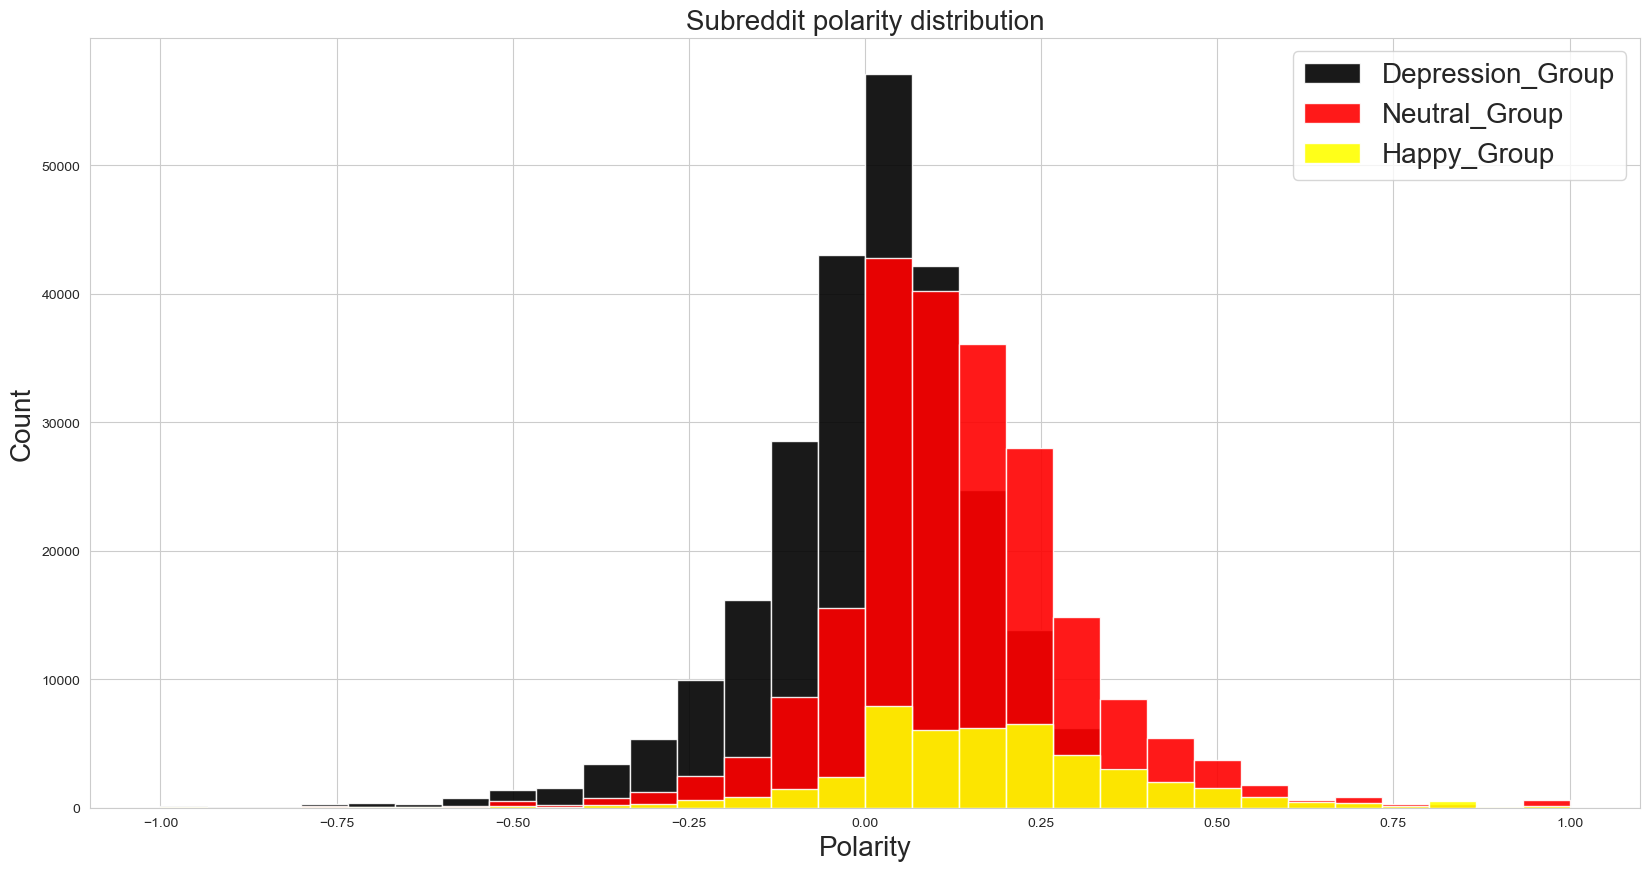

,class_group,before_polarity_filtering
0,Depression_Group,263525
1,Neutral_Group,217441
2,Happy_Group,45690


In [25]:
Depression_Group_df  = whole_df[whole_df['class_group'] == 'Depression_Group']
Neutral_Group_df  = whole_df[whole_df['class_group'] == 'Neutral_Group']
Happy_Group_df  = whole_df[whole_df['class_group'] == 'Happy_Group']

print(f'Depression_Group_df lenghth is  : {len(Depression_Group_df)}')
print()
print(f'Neutral_Group_df lenghth is  : {len(Neutral_Group_df)}')
print()
print(f'Happy_Group_df lenghth is  : {len(Happy_Group_df)}')
print()

from matplotlib import pyplot
plt.figure(figsize=(20,10))
bins = 30 # np.linspace(-.9, .9, 50)

pyplot.hist(Depression_Group_df['polarity'], bins, alpha=0.9, label='Depression_Group',color='black')
pyplot.hist(Neutral_Group_df['polarity'], bins, alpha=0.9, label='Neutral_Group',color='red')
pyplot.hist(Happy_Group_df['polarity'], bins, alpha=0.9, label='Happy_Group',color='yellow')

plt.xlabel('Polarity',fontsize =20)
plt.ylabel('Count',fontsize =20)
pyplot.legend(loc='upper right',fontsize=20)
plt.title('Subreddit polarity distribution',fontsize =20)

pyplot.show()

counts_before_polarity_filtering = pd.DataFrame({
    'class_group': ['Depression_Group', 'Neutral_Group', 'Happy_Group'],
    'before_polarity_filtering': [len(Depression_Group_df), len(Neutral_Group_df), len(Happy_Group_df)],
})
counts_before_polarity_filtering


#### Polarity sampling score range 
- depression group polarity : -1 ~ 0.2
- neutral group polarity : -0.3 ~ 0.3
- depression group polarity : - 0.2 ~ 1

Depression_Group_df lenghth is  : 235457

Neutral_Group_df lenghth is  : 186095

Happy_Group_df lenghth is  : 44260



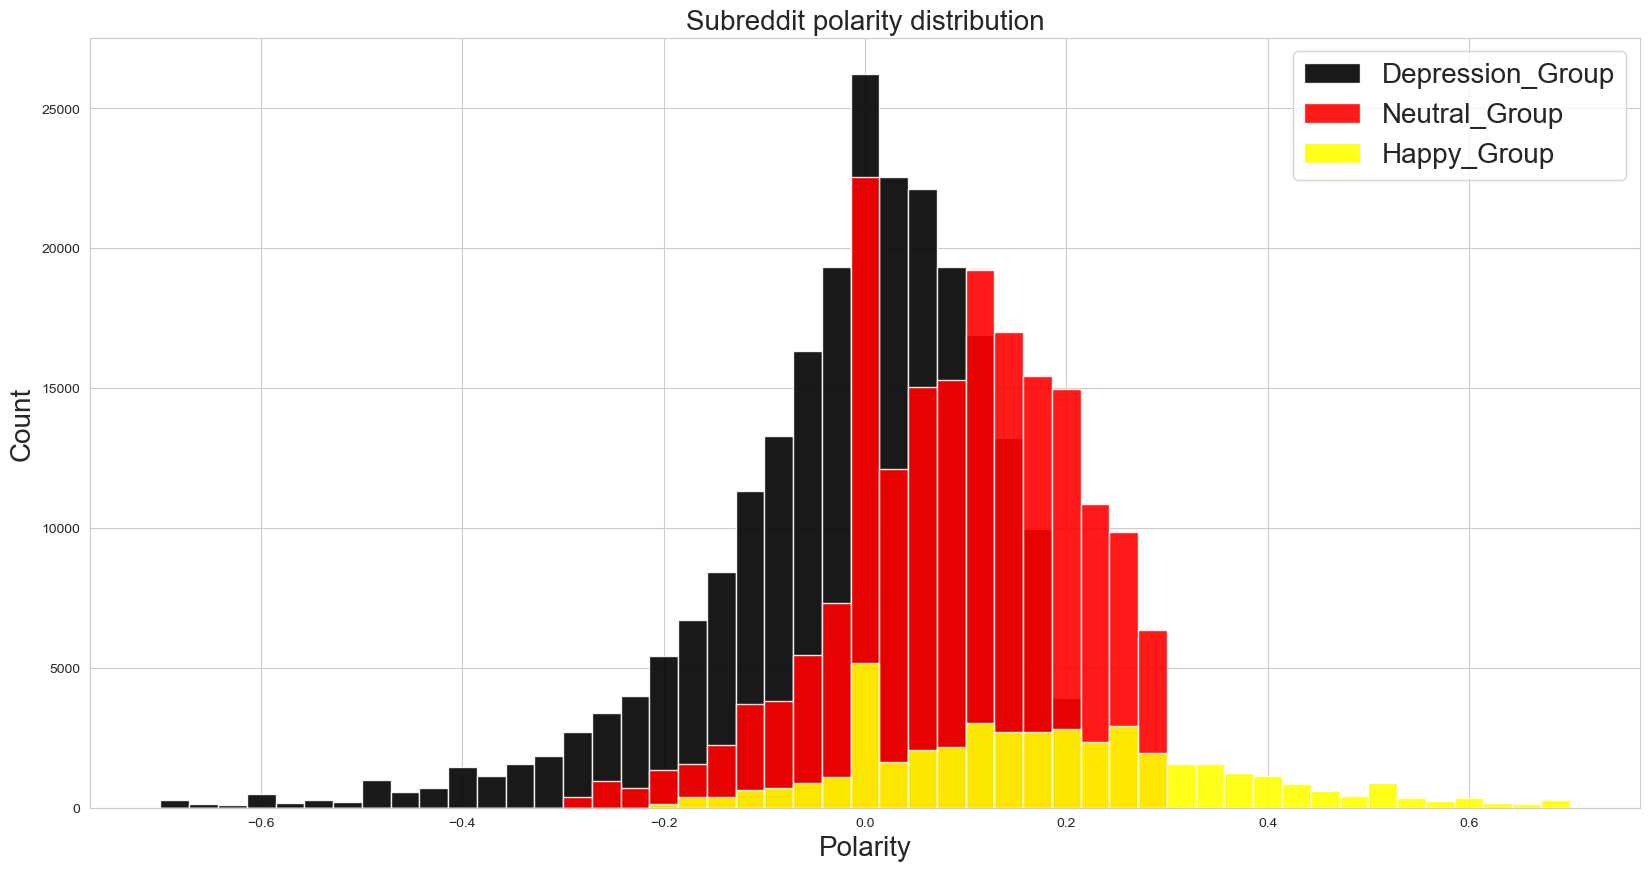

,class_group,after_polarity_filtering
0,Depression_Group,235457
1,Neutral_Group,186095
2,Happy_Group,44260


In [26]:
Depression_Group_df = Depression_Group_df[Depression_Group_df['polarity']< 0.2]
Neutral_Group_df =Neutral_Group_df.loc[(Neutral_Group_df['polarity'] > -0.3) & (Neutral_Group_df['polarity'] < 0.3)]
Happy_Group_df = Happy_Group_df[Happy_Group_df['polarity'] > -0.2]
print(f'Depression_Group_df lenghth is  : {len(Depression_Group_df)}')
print()
print(f'Neutral_Group_df lenghth is  : {len(Neutral_Group_df)}')
print()
print(f'Happy_Group_df lenghth is  : {len(Happy_Group_df)}')
print()

plt.figure(figsize=(20,10))
bins = np.linspace(-.7, .7, 50)

pyplot.hist(Depression_Group_df['polarity'], bins, alpha=0.9, label='Depression_Group',color='black')
pyplot.hist(Neutral_Group_df['polarity'], bins, alpha=0.9, label='Neutral_Group',color='red')
pyplot.hist(Happy_Group_df['polarity'], bins, alpha=0.9, label='Happy_Group',color='yellow')

plt.xlabel('Polarity',fontsize =20)
plt.ylabel('Count',fontsize =20)
pyplot.legend(loc='upper right',fontsize=20)
plt.title('Subreddit polarity distribution',fontsize =20)

pyplot.show()

counts_after_polarity_filtering = pd.DataFrame({
    'class_group': ['Depression_Group', 'Neutral_Group', 'Happy_Group'],
    'after_polarity_filtering': [len(Depression_Group_df), len(Neutral_Group_df), len(Happy_Group_df)],
})
counts_after_polarity_filtering


In [27]:
### quality check 

In [28]:
Happy_Group_df.polarity.min() 

-0.19999999999999998

In [29]:
### download whole df csv before downsample with fraction   
frames = [Depression_Group_df, Neutral_Group_df,Happy_Group_df]
final_preprocessed_whole_df = pd.concat(frames)
final_preprocessed_whole_df.to_csv(OUTPUT_DIR / 'final_preprocessed_whole_df.csv', index=False)

In [30]:
Depression_Group_df.sample(frac=0.19, replace=True, random_state=1)

,subreddit,author,over_18,link_flair_text,title,selftext,url,created_utc,title_with_selftext,title_with_selftext_cleaned,polarity,class_group
141414,depression,[deleted],False,None,"I've been chronically depressed for 4 years, n...","First of all, it's impossible to begin the sto...",http://www.reddit.com/r/depression/comments/2o...,2014-12-04 13:51:15,"I've been chronically depressed for 4 years, n...",chronically depressed year getting worse need...,-0.004304,Depression_Group
290280,depression,bbybroccoli,False,None,Has anyone had bad side effects on Wellbutrin ...,"I just started it last Wednesday, 150 mg in th...",https://www.reddit.com/r/depression/comments/4...,2016-08-22 15:12:43,Has anyone had bad side effects on Wellbutrin ...,anyone bad side effect wellbutrin bupropion ...,0.154464,Depression_Group
255110,depression,onlyindarkness,False,None,I want to live at the hospital.,The therapist I met with Friday afternoon aske...,https://www.reddit.com/r/depression/comments/4...,2016-04-17 02:03:20,I want to live at the hospital. The therapist ...,want live hospital therapist met friday after...,0.037710,Depression_Group
8506,AnxietyDepression,WiggleFriend,False,NaN,I'm starting to hear voices again,I haven't told anyone how much everything is g...,https://www.reddit.com/r/AnxietyDepression/com...,2020-03-18 04:52:39,I'm starting to hear voices again I haven't to...,starting hear voice told anyone much everythin...,-0.084694,Depression_Group
289502,depression,AnotherBurnerFml,False,None,Is anyone else's depression caused by light?,Over the last several years I have slowly disc...,https://www.reddit.com/r/depression/comments/4...,2016-08-20 02:09:16,Is anyone else's depression caused by light? O...,anyone else depression caused light last seve...,0.075231,Depression_Group
...,...,...,...,...,...,...,...,...,...,...,...,...
14793,AnxietyDepression,shebasqueen,False,NaN,DAE feel bad right after a nice interaction? (...,i’ve started to connect with people more which...,https://www.reddit.com/r/AnxietyDepression/com...,2021-05-10 22:57:04,DAE feel bad right after a nice interaction? (...,dae feel bad right nice interaction advice p...,0.125265,Depression_Group
81554,depression,snowaway9,False,None,I thought these were supposed to be the best y...,"I've never posted on here before, but today it...",http://www.reddit.com/r/depression/comments/1s...,2013-12-14 20:55:56,I thought these were supposed to be the best y...,thought supposed best year life never posted ...,-0.030070,Depression_Group
19620,depression,knegil,False,None,I want you to read this,I've been depressed for I don't know how long....,http://www.reddit.com/r/depression/comments/um...,2012-06-05 22:17:28,I want you to read this I've been depressed fo...,want read depressed know long year two year ...,0.033359,Depression_Group
168806,depression,oOMissOo,False,None,I Hate My School,I want to leave my school badly and get a with...,http://www.reddit.com/r/depression/comments/32...,2015-04-14 06:08:45,I Hate My School I want to leave my school bad...,hate school want leave school badly get draw l...,-0.187500,Depression_Group


In [31]:
Neutral_Group_df.sample(frac=0.24, replace=True, random_state=1)

,subreddit,author,over_18,link_flair_text,title,selftext,url,created_utc,title_with_selftext,title_with_selftext_cleaned,polarity,class_group
223538,webdev,Mr_Crick84,False,None,Using HTML/CSS vs Page builders,A few months ago i started learning CSS and HT...,https://www.reddit.com/r/webdev/comments/fltp5...,2020-03-20 11:47:45,Using HTML/CSS vs Page builders A few months a...,using html cs v page builder month ago started...,0.262500,Neutral_Group
322712,technology,AdityaY,False,None,My favorite Siri question/response combo?,"My friend: ""Make me a sandwich.""\nSiri: ""I don...",http://www.reddit.com/r/technology/comments/lo...,2011-10-25 06:07:33,My favorite Siri question/response combo? My f...,favorite siri question response combo friend ...,0.093750,Neutral_Group
19946,webdev,Str8OutaCompUSA,False,None,PHP to get a web url or the title of a page,I have web forms I'm tweaking and I'd like to ...,http://www.reddit.com/r/webdev/comments/1cvrjq...,2013-04-22 19:27:04,PHP to get a web url or the title of a page I ...,php get web url title page web form tweaking l...,0.106667,Neutral_Group
171183,webdev,RetPallylol,False,None,"Beginner to webdev, how hard is it to change D...",I'm looking to create a website soon for perso...,https://www.reddit.com/r/webdev/comments/9oxau...,2018-10-17 10:08:10,"Beginner to webdev, how hard is it to change D...",beginner webdev hard change dns server domain...,0.023333,Neutral_Group
71274,webdev,oldirtyjappy,False,None,How to use CSS to decorate the background of m...,I'm thinking of using CSS to implement a decor...,http://www.reddit.com/r/webdev/comments/3ez9x7...,2015-07-29 02:27:45,How to use CSS to decorate the background of m...,use cs decorate background navbar thinking us...,0.286429,Neutral_Group
...,...,...,...,...,...,...,...,...,...,...,...,...
53108,webdev,tp02ga,False,None,"Do you want to start a business, but haven't d...","Question for you:\n\n""Do you want to start a b...",http://www.reddit.com/r/webdev/comments/2p4a5m...,2014-12-12 22:08:28,"Do you want to start a business, but haven't d...",want start business done yet yes question ...,0.207983,Neutral_Group
64659,webdev,Stephen110,False,None,This is going to be incredibly unpopular,"**Experiment over, thanks for participating!**...",http://www.reddit.com/r/webdev/comments/3551xi...,2015-05-07 04:07:16,This is going to be incredibly unpopular **Exp...,going incredibly unpopular experiment thank...,0.069252,Neutral_Group
92969,datascience,Tarneks,False,Discussion,What is the difference between an online maste...,I see a lot of comments promoting online maste...,https://www.reddit.com/r/datascience/comments/...,2022-12-31 04:58:34,What is the difference between an online maste...,difference online master v conventional master...,0.071230,Neutral_Group
47086,webdev,zakkwylde123,False,None,Publishing a website... How?!,"Sup, is there any place that I can ADVERTISE a...",http://www.reddit.com/r/webdev/comments/2gekqz...,2014-09-14 22:10:43,"Publishing a website... How?! Sup, is there an...",publishing website sup place advertise p...,0.200000,Neutral_Group


In [32]:
len(Happy_Group_df)

44260

Depression_Group_df lenghth is  : 44737

Neutral_Group_df lenghth is  : 44663

Happy_Group_df lenghth is  : 44260



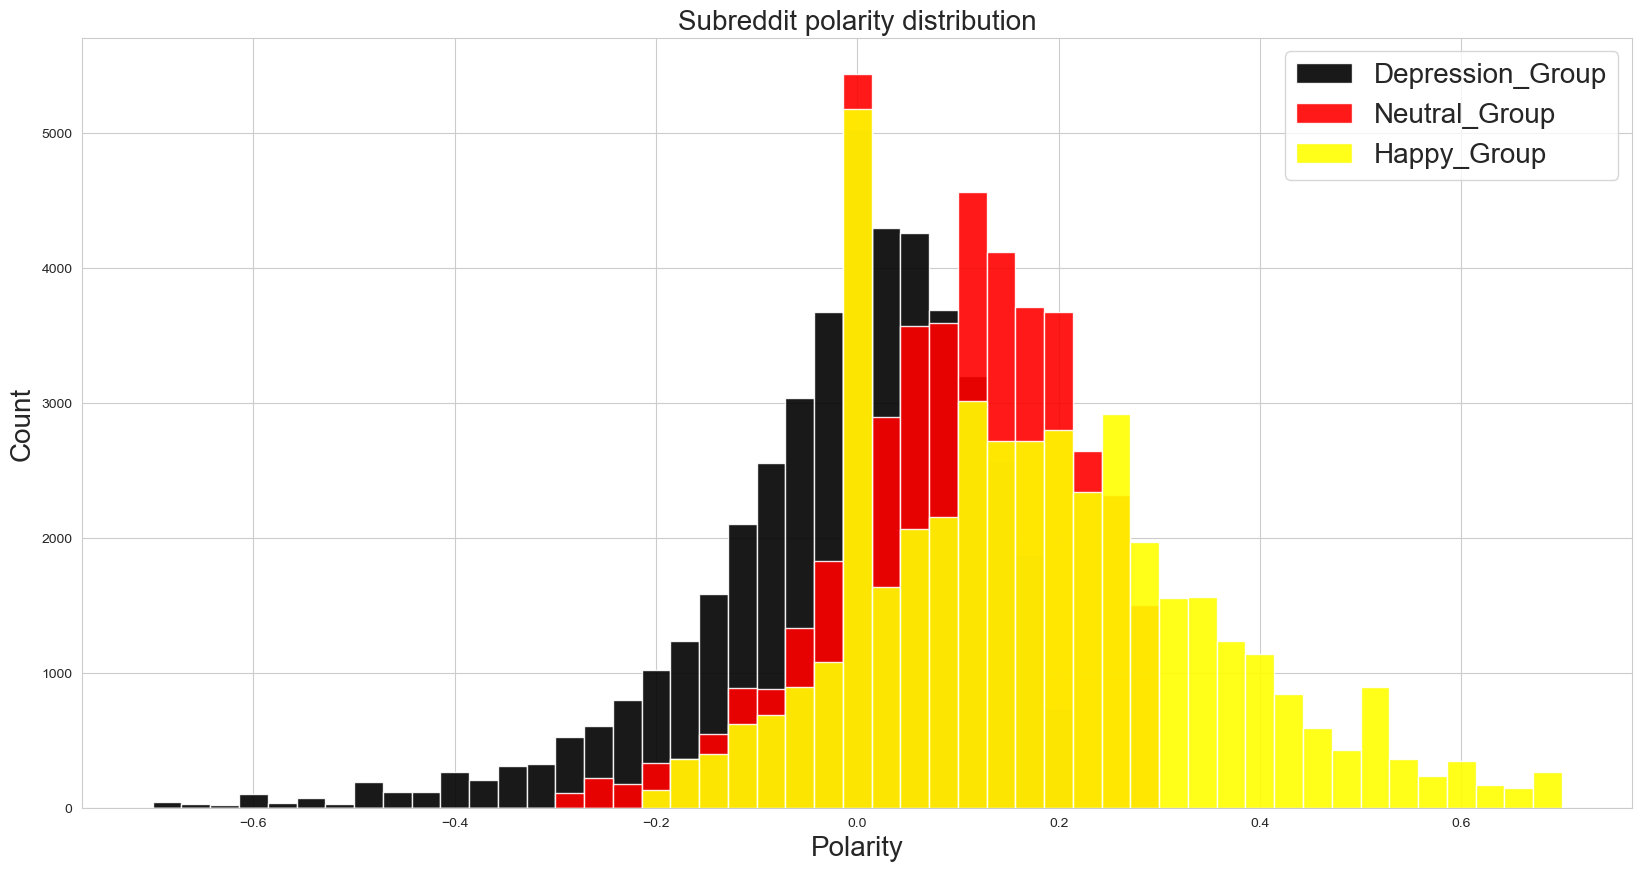

,class_group,records
0,Depression_Group,44737
1,Neutral_Group,44663
2,Happy_Group,44260


In [33]:
Depression_Group_df = Depression_Group_df.sample(frac=0.19, replace=True, random_state=1)
Neutral_Group_df = Neutral_Group_df.sample(frac=0.24, replace=True, random_state=1)
Happy_Group_df
print(f'Depression_Group_df lenghth is  : {len(Depression_Group_df)}')
print()
print(f'Neutral_Group_df lenghth is  : {len(Neutral_Group_df)}')
print()
print(f'Happy_Group_df lenghth is  : {len(Happy_Group_df)}')
print()

plt.figure(figsize=(20,10))
bins = np.linspace(-.7, .7, 50)

pyplot.hist(Depression_Group_df['polarity'], bins, alpha=0.9, label='Depression_Group',color='black')
pyplot.hist(Neutral_Group_df['polarity'], bins, alpha=0.9, label='Neutral_Group',color='red')
pyplot.hist(Happy_Group_df['polarity'], bins, alpha=0.9, label='Happy_Group',color='yellow')

plt.xlabel('Polarity',fontsize =20)
plt.ylabel('Count',fontsize =20)
pyplot.legend(loc='upper right',fontsize=20)
plt.title('Subreddit polarity distribution',fontsize =20)

pyplot.show()

counts_after_class_balancing = pd.DataFrame({
    'class_group': ['Depression_Group', 'Neutral_Group', 'Happy_Group'],
    'records': [len(Depression_Group_df), len(Neutral_Group_df), len(Happy_Group_df)],
})
counts_after_class_balancing


### Final pre-processsing step 

In [34]:
frames = [Depression_Group_df, Neutral_Group_df,Happy_Group_df]
final_whole_df = pd.concat(frames)

In [35]:
final_whole_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133660 entries, 141414 to 100026
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   subreddit                    133660 non-null  object        
 1   author                       133660 non-null  object        
 2   over_18                      133660 non-null  bool          
 3   link_flair_text              19278 non-null   object        
 4   title                        133660 non-null  object        
 5   selftext                     133660 non-null  object        
 6   url                          133658 non-null  object        
 7   created_utc                  133660 non-null  datetime64[ns]
 8   title_with_selftext          133660 non-null  object        
 9   title_with_selftext_cleaned  133660 non-null  object        
 10  polarity                     133660 non-null  float64       
 11  class_group               

In [36]:
### positive / negative extreme case experiment with polarity score

In [37]:
## positive case

In [38]:
positive_10_extreme_example = final_whole_df[final_whole_df['polarity']==1.0]
positive_10_extreme_example['title_with_selftext'].tail(10).tolist()

['I had a wonderful, dream maybe a promotion 😊 I dreamed that i got a daughter, holding her in my arms. Feeling the warmth of a baby, feeling the way my dad felt.',
 'My best friend’s toddler said my name today It’s one of 12 words she can say and the only name other than Mama and Dada.',
 'I always forget my cake day but I just realized it’s on May 4th!!! This is awesome!!!!',
 "Someone once told me I wasn't meant for college, so I went and got a Bachelor of Science. Someone once told me that I wasn't meant for college and at best could go to a community college. I am graduating this fall with a Bachelor of Science in Information Science and Cybersecurity. ",
 "I'd like to take a moment to thank the reddit community Thank you reddit, for helping me in my toughest times. Thank you, those who gave me awards. Thank you, for giving me support throughout my depression. Thank you, reddit, you're the best.",
 'I’m marrying my best friend in 36 hours! Can’t wait!',
 'Who has a perfect relatio

In [39]:
positive_10_extreme_example['title_with_selftext_cleaned'].tail(10).tolist()

['wonderful  dream maybe promotion   dreamed got daughter  holding arm  feeling warmth baby  feeling way dad felt ',
 'best friend toddler said name today one word say name mama dada ',
 'always forget cake day realized may 4th    awesome    ',
 'someone told meant college  went got bachelor science  someone told meant college best could go community college  graduating fall bachelor science information science cybersecurity  ',
 'like take moment thank reddit community thank reddit  helping toughest time  thank  gave award  thank  giving support throughout depression  thank  reddit  best ',
 'marrying best friend hour  wait ',
 'perfect relationship   http   reddit com poll j7up2a ',
 'best day life like  ',
 'wich best  http   reddit com poll lanlwn ',
 'easter outfit turn  best could  amp  x200b http   preview redd s373o81kmjq61 jpg width amp format pjpg amp auto webp amp f3154a0c10b641f988788a1d2b00b67361ba0414']

In [40]:
## negative case

In [41]:
negative_10_extreme_example = final_whole_df[final_whole_df['polarity']==-1.0]
negative_10_extreme_example['title_with_selftext'].tail(10).tolist()

["Does anyone have time to chat with me? I'm having a really awful day. I've got skype.",
 "Horrible therapist I told my mom about my deppression, and she took me to see a therapist, but they think I instead  have autism (don't we all) and instead of helping me, they treat me like a frikin puppy",
 "I feel lost That's the only way I can describe it. I don't know what I'm doing. Where I'm going. What I should be doing. Everything just feels bleak.",
 "What would you tell me? Dear Reddit,\nI've reached out to the virtual void to plead for a reason, any reason, on why I shouldn't commit suicide. I'm fully prepared. Please, enlighten me. What would you tell me? In fact, what would you tell your friends, family, or just a lone stranger like me on why he/she shouldn't commit suicide. This is hypothetical, and not in a cruel way. Just what would you tell me? ",
 "Should I self harm? I feel like I'm such a horrible, irredeemable scumbag that I need to to cut myself",
 "I'm terrified and scared

In [42]:
negative_10_extreme_example['title_with_selftext_cleaned'].tail(10).tolist()

['anyone time chat  really awful day  got skype ',
 'horrible therapist told mom deppression  took see therapist  think instead  autism   instead helping  treat like frikin puppy',
 'feel lost way describe  know  going   everything feel bleak ',
 'would tell  dear reddit reached virtual void plead reason  reason  commit suicide  fully prepared  please  enlighten  would tell  fact  would tell friend  family  lone stranger like commit suicide  hypothetical  cruel way  would tell  ',
 'self harm  feel like horrible  irredeemable scumbag need cut',
 'terrified scared transfer school grade absolutely horrible ashamed know one hole dig',
 'terrible reaction one pill  losing hope   ',
 'anyone else find angrier  suffering depression five year noticed worst day tend horrible temper followed bout cry  anyone else experience ',
 'online chat hour  want talk someone phone  hearing someone voice nerve racking  tried looking online crappy tabletthat support flash phone computer  sitting 2am get  tr

In [43]:
## download to csv 

In [44]:
final_whole_df.to_csv(OUTPUT_DIR / 'final_preprocessed_df.csv', index=False)

In [45]:
final_whole_df = pd.read_csv(OUTPUT_DIR / 'final_preprocessed_df.csv')
# No Unnamed: 0 column is created because outputs are saved with index=False.
# final_whole_df.drop(['Unnamed: 0'], axis = 1, inplace = True)


/var/folders/g6/l_khc3xx5djcv7507rvj73pw0000gn/T/ipykernel_66881/2852366160.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  final_whole_df = pd.read_csv(OUTPUT_DIR / 'final_preprocessed_df.csv')


In [46]:
### Export summary tables for manuscript reporting
filtering_summary = counts_before_polarity_filtering.merge(
    counts_after_polarity_filtering,
    on='class_group',
    how='inner'
)
filtering_summary['excluded_by_filtering'] = (
    filtering_summary['before_polarity_filtering'] - filtering_summary['after_polarity_filtering']
)
filtering_summary['retention_rate'] = (
    filtering_summary['after_polarity_filtering'] / filtering_summary['before_polarity_filtering'] * 100
).round(2)

final_class_distribution = counts_after_class_balancing.copy()

counts_before_polarity_filtering.to_csv(OUTPUT_DIR / 'class_counts_before_filtering.csv', index=False)
counts_after_polarity_filtering.to_csv(OUTPUT_DIR / 'class_counts_after_filtering.csv', index=False)
filtering_summary.to_csv(OUTPUT_DIR / 'filtering_summary.csv', index=False)
final_class_distribution.to_csv(OUTPUT_DIR / 'final_class_distribution.csv', index=False)

print('Filtering summary')
display(filtering_summary)
print('Final class distribution')
display(final_class_distribution)


Filtering summary


,class_group,before_polarity_filtering,after_polarity_filtering,excluded_by_filtering,retention_rate
0,Depression_Group,263525,235457,28068,89.35
1,Neutral_Group,217441,186095,31346,85.58
2,Happy_Group,45690,44260,1430,96.87


Final class distribution


,class_group,records
0,Depression_Group,44737
1,Neutral_Group,44663
2,Happy_Group,44260
